In [2]:
import numpy as np
import matplotlib.pyplot as plt

**Exercise 4.2.1**

In each case, show that the given $g(x)$ has a fixed point at the given $p$ and use (4.2.3) to show that fixed-point iteration can converge to it.

(a) $g(x)=1+x-1/9x^2$, $p=3$

$g(3)=1+3-1/9(3)^2=3$, so $p$ is a fixed point.

$g'(x)=1-2/9x$, $|g'(3)|=|1-2/3|=1/3<1$, so fixed-point iteration can converge to it.

(b) $g(x)=\pi+1/4\sin(x)$. $p=\pi$

$g(\pi)=\pi+1/4\sin(\pi)=\pi$, so $p$ is a fixed point.

$g'(x)=1/4\cos(x)$, $|g'(\pi)|=|1/4\cos(\pi)|=1/4<1$, so fixed-point iteration can converge to it.

(c) $g(x)=x+1-\tan(x/4)$, $p=\pi$

$g(\pi)=\pi+1-\tan(\pi/4)=\pi$, so $p$ is a fixed point.

$g'(x)=1-1/4\sec^2(x/4),|g'(\pi)|=|1-1/4*2|=1/2<1$, so fixed-point iteration can converge to it.

**Exercise 4.2.2**

For each case in the preceding problem, apply 25 fixed-point iterations starting from $x_1=1$. Make a log-linear plot of the error to verify linear convergence. Then, use numerical values of the error to determine an approximate value for $\sigma$ in (4.2.4).

In [21]:
def fixed_point_iteration(g, x_0 = 1.0):
    x = np.zeros(25)
    x[0] = x_0
    for i in range(25 - 1):
        x[i + 1] = g(x[i])
    return x

def log_linear_error_plot(x, p):
    err = abs(x - p)

    linear_fit = np.polyfit(np.arange(5, 25 + 1), np.log(err[4:]), 1)
    sigma = np.exp(linear_fit[0])

    plt.semilogy(err, "-o")
    plt.xlabel("Iteration number")
    plt.ylabel("Error")
    plt.show()

    print(f"sigma = {sigma}")

(a)

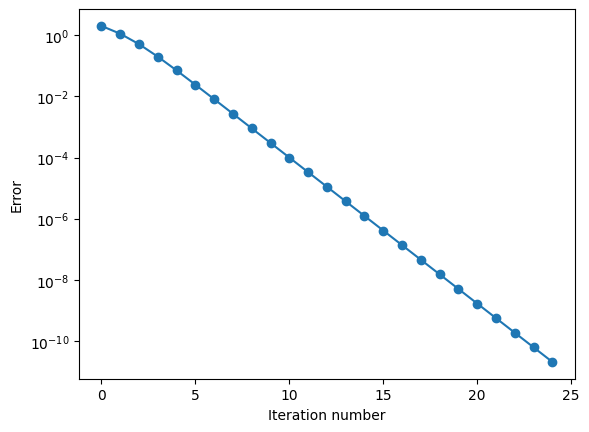

sigma = 0.3335518443031522


In [14]:
def g(x):
    return 1 + x - (1 / 9) * (x ** 2)

x = fixed_point_iteration(g)
log_linear_error_plot(x, 3)



(b)

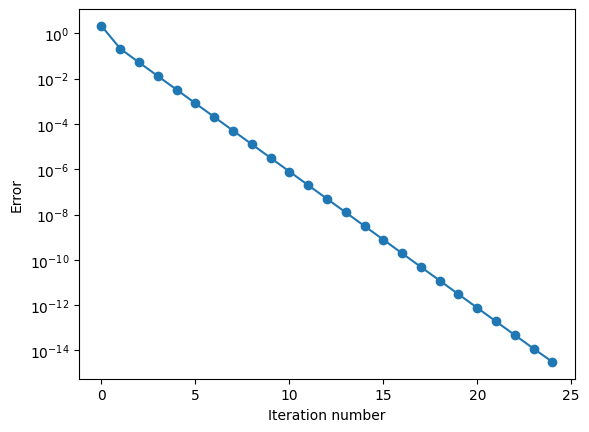

sigma = 0.250189718740918


In [15]:
def g(x):
    return np.pi + (1 / 4) * np.sin(x)

x = fixed_point_iteration(g)
log_linear_error_plot(x, np.pi)

(c)

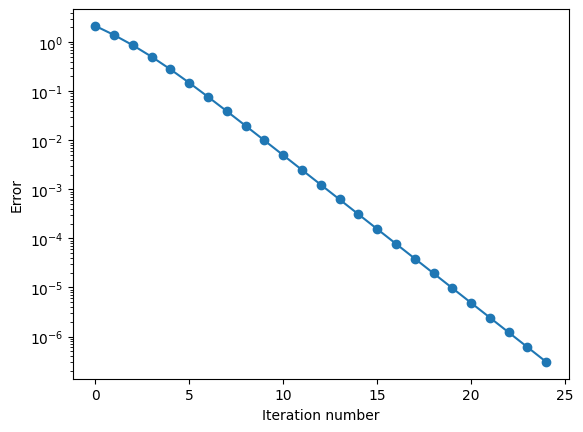

sigma = 0.5016508694057623


In [16]:
def g(x):
    return x + 1 - np.tan(x / 4)

x = fixed_point_iteration(g)
log_linear_error_plot(x, np.pi)

**Exercise 4.2.6**

(a) Show that $p=1/3$ is a fixed point of $g(x)=2x-3x^2$.

$g(1/3)=2(1/3) - 3(1/3)^2=2/3-1/3=1/3$, so $p$ is a fixed-point.

(b) Find $g'(1/3)$. How does this affect (4.2.3)?

$g'(x)=2-6x$, $g'(1/3)=2-6/3=0$.

To arrive at (4.2.3), we make the approximation $g(p+\epsilon_k)\approx p+\epsilon_k g'(p)$. If $g'(x)=0$, it would seem to follow that $g(p+\epsilon_k)\approx p$.

(c) Do an experiment with fixed-point iteration on $g$ to converge to $p=1/3$. Is the convergence a straight line on a log-linear plot?

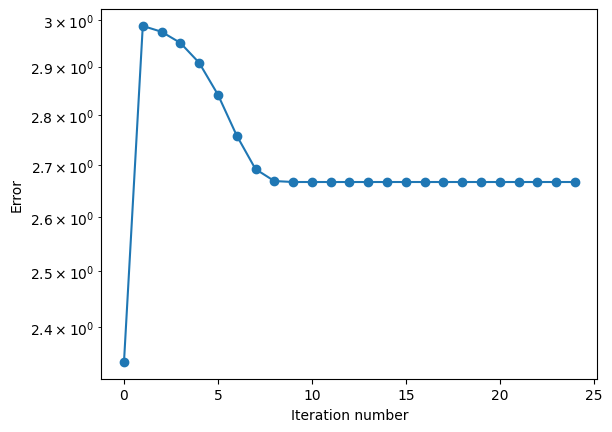

sigma = 0.9976952174153798


In [40]:
def g(x):
    return 2 * x - 3 * (x ** 2)

x = fixed_point_iteration(g, x_0 = 0.66)
log_linear_error_plot(x, 3)

It seems like $x_0>0.66$ causes the iteration to not converge, interesting... It's also definitely not a straight line (unless you count a line with slope $0$, haha).

**Exercise 4.2.7**

Consider the iteration

$$x_{k+1}=x_k-\frac{f(x_k)}{c},k=0,1,\dots$$

Suppose $f(p)=0$ and that $f'(p)>0$ exists. Find one or more conditions on $c$ such that the iteration converges to $p$.

Fixed-point iteration will converge to $p$ if $|g'(p)|<1$, where $g(x)=x-f(x)/c$. $g'(x)=1-f'(x)/c$, so $g'(p)=1-f'(p)/c$. We have the convergence condition that $|1-f'(p)/c|<1\to -1<1-f'(p)/c<1\to f'(p)/c<2\to c>f'(p)/2$. For this iteration to converge, $c$ must be greater than half the derivative at $p$.

**Exercise 4.3.4**

Plot the function $f(x)=x^{-2}-\sin(x)$ on the interval $x\in[0.5,10]$. For each initial value $x_1=1,x_1=2,\dots,x_1=7$, apply Function 4.3.1 to $f$, and make a table showing $x_1$ and the resulting root found by the method. In which case does the iteration converge to a root other than the one closest to it? Use the plot to explain why that happened.

In [7]:
def newton(f, dfdx, x1):
    """
    newton(f, dfdx, x1)

    Use Newton's method to find a root of f starting from x1, where dfdx is the
    derivative of f. Returns a vector of root estimates.
    """
    # Operating parameters.
    eps = np.finfo(float).eps
    funtol = 100 * eps
    xtol = 100 * eps
    maxiter = 40

    x = np.zeros(maxiter)
    x[0] = x1
    y = f(x1)
    dx = np.inf  # for initial pass below
    k = 0

    while (abs(dx) > xtol) and (abs(y) > funtol) and (k < maxiter):
        dydx = dfdx(x[k])
        dx = -y / dydx  # Newton step
        x[k + 1] = x[k] + dx  # new estimate

        k = k + 1
        y = f(x[k])

    if k == maxiter:
        print("WARNING: Maximum number of iterations reached.")

    return x[:k+1]

x_1 = 1, root = 1.068223544197249
x_1 = 2, root = 6.3083168252685535
x_1 = 3, root = 3.032645418388756
x_1 = 4, root = 3.032645418388756
x_1 = 5, root = 9.4134928031701
x_1 = 6, root = 6.3083168252685535
x_1 = 7, root = 6.3083168252685535


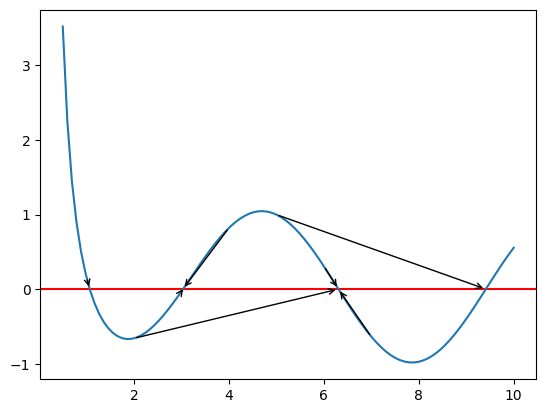

In [17]:
def f(x):
    return (x ** -2) - np.sin(x)

def dfdx(x):
    return -2 * (x ** -3) - np.cos(x)

x = np.linspace(0.5, 10, 100)
y = np.vectorize(f)(x)

plt.axhline(0, color = "r")
plt.plot(x, y)

for x_1 in range(1, 7 + 1):
    root = newton(f, dfdx, x_1)[-1]
    # plt.arrow isn't recommended so this line looks crazy
    plt.annotate("", xytext = (x_1, f(x_1)), xy = (root, f(root)), arrowprops = dict(arrowstyle = "->"))
    print(f"x_1 = {x_1}, root = {root}")

As expected by Newton's method, the found root is the root closest to the intersection between the tangent line at $x_1$ and $f$.

**Exercise 4.3.7**

In the case of a multiple root, where $f(r)=f'(r)=0$, the derivation of the quadratic error convergence leading up to (4.3.7) is invalid.

(b) Use Function 4.3.1 to find a root of $f(x)=e^{x+1}-2-x$ starting at $x_1=0$ and make a plot of the errors showing that the convergence is linear.

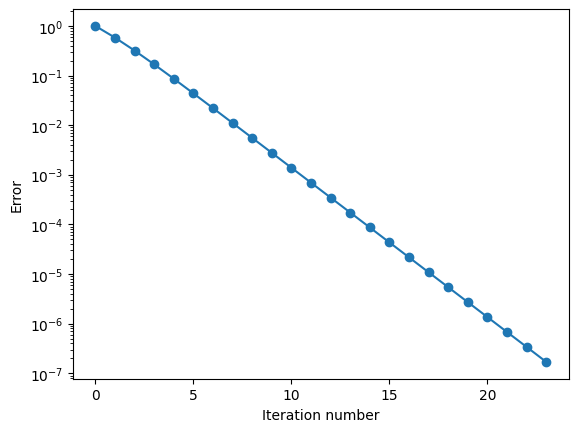

In [23]:
def f(x):
    return np.exp(x + 1) - 2 - x

def dfdx(x):
    return np.exp(x + 1) - 1

root_progression = newton(f, dfdx, 0)
errors = abs(root_progression - (-1))

plt.semilogy(errors, "-o")
plt.xlabel("Iteration number")
plt.ylabel("Error")
plt.show()

**Exercise 4.3.8**

In Function 4.3.1 and elsewhere, the actual error is not available, so we use $|x_k-x_{k-1}|$ as an approximate indicator of error to determine when to stop the iteration. Find an example that foils this indictor; that is, a sequence ${x_k}$ such that $\lim_{k\to\infty}(x_k-x_{k-1})=0$, but ${x_k}$ diverges. (Hint: You have seen such sequences in calculus.) While you do *not* need to show that the sequence is produced by Newton's method for any particular $f$, this does justify the use of residual tolerances and safety valves in the code.

Define ${x_k}=\ln(k)$. $\lim_{k\to\infty}(x_k-x_{k-1})=\lim(\ln(k)-\ln(k-1))=0$, but $\lim x_k=\lim ln(k)=\infty$. This counts, right?

**Exercise 4.4.5**

Show analytically that the secant method converges in one step for a linear function, regardless of the initialization.

For some linear $f(x)=ax+b$, $f(x)=0\to x=-b/a$. We must show $x_3=-b/a$ regardless of $x_1,x_2$.

$$\begin{align*}
x_3&=x_2-\frac{f(x_2)(x_2-x_1)}{f(x_2)-f(x_1)}\\
&=x_2-\frac{(ax_2+b)(x_2-x_1)}{(ax_2+b)-(ax_1+b)}\\
&=x_2-\frac{(ax_2+b)(x_2-x_1)}{a(x_2-x_1)}\\
&=x_2-\frac{a}{a}x_2-\frac{b}{a}\\
&=\frac{-b}{a}
\end{align*}$$

**Exercise 4.4.7**

Let $f(x)=x^2$. Show that if $(1/x_1)$ and $(1/x_2)$ are positive integers, and the secant iteration is applied, then the sequence $1/x_1,1/x_2,1/x_3,\dots$ is a Fibonacci sequence, i.e. they satisfy $x_{k+1}=x_k+x_{k-1}$.

We start with the secant iteration sequence definition and derive the reciprocal of the Fibonacci sequence.

$$\begin{align*}
x_{k+1}&=x_k-\frac{f(x_k)(x_k-x_{k-1})}{f(x_k)-f(x_{k-1})}\\
&=x_k-\frac{x_k^2(x_k-x_{k-1})}{x_k^2-x_{k-1}^2}\\
&=x_k-\frac{x_k^2(x_k-x_{k-1})}{(x_k+x_{k-1})(x_k-x_{k-1})}\\
&=\frac{x_k^2+x_kx_{k-1}-x_k^2}{x_k+x_{k-1}}\\
&=\frac{x_kx_{k-1}}{x_k+x_{k-1}}\\
1/x_{k+1}&=\frac{x_k+x_{k-1}}{x_kx_{k-1}}\\
&=\frac{1}{x_{k-1}}+\frac{1}{x_k}
\end{align*}$$

This can pretty trivially be turned into a proof by induction, which I have left as an exercise to the grader.

**Exercise 4.5.5**

Suppose one wants to find the points on the ellipsoid $x^2/25+y^2/16+z^2/9=1$ that are closest to and farthest from the point $(5,4,3)$. The method of Lagrange multipliers implies that any such point satisfies

$$\begin{align*}
x-5&=\frac{\lambda x}{25},\\
y-4&=\frac{\lambda y}{16},\\
z-3&=\frac{\lambda z}{9},\\
1&=\frac{1}{25}x^2+\frac{1}{16}y^2+\frac{1}{9}z^2
\end{align*}$$

for an unknown value of $\lambda$.

(a) Write out this system in the form $f(u)=0$. (Note that the system has four variables to go with the four equations.)

$$\begin{align*}f(u)&=[f_1,f_2,f_3,f_4],\\
f_1&=\frac{u_4\cdot u_1}{25}-u_1+5,\\
f_2&=\frac{u_4\cdot u_2}{16}-u_2+4,\\
f_3&=\frac{u_4\cdot u_3}{9}-u_3+3,\\
f_4&=\frac{1}{25}u_1^2+\frac{1}{16}u_2^2+\frac{1}{9}u_3^2-1,\\
u&=[x,y,z,\lambda]\end{align*}$$

(b) Write out the Jacobian matrix of this system.

$$J(u)=\begin{bmatrix}
u_4/25-1 & 0 & 0 & u_1/25\\
0 & u_4/16-1 & 0 & u_2/16\\
0 & 0 & u_4/9-1 & u_3/9\\
2/25u_1 & 2/16u_2 & 2/9u_3 & 0
\end{bmatrix}$$

(c) Use Function 4.5.2 with different initial guesses to find the two roots of this system. Which is the closest point to $(5, 4, 3)$, and which is the farthest?

In [26]:
def newtonsys(f, jac, x1):
    """
        newtonsys(f, jac, x1)

    Use Newton's method to find a root of a system of equations, starting from x1. The
    function f should return the residual vector, and the function jac should return 
    the Jacobian matrix. Returns root estimates as a matrix, one estimate per column.
    """
    # Operating parameters.
    funtol = 1000 * np.finfo(float).eps
    xtol = 1000 * np.finfo(float).eps
    maxiter = 40

    x = np.zeros((maxiter + 1, len(x1)))
    x[0] = x1
    y, J = f(x1), jac(x1)
    dx = 10.0  # for initial pass below
    k = 0

    while (np.linalg.norm(dx) > xtol) and (np.linalg.norm(y) > funtol) and (k < maxiter):
        dx = -np.linalg.lstsq(J, y)[0]  # Newton step
        x[k+1] = x[k] + dx

        k = k + 1
        y, J = f(x[k]), jac(x[k])

    if k == maxiter:
        print("WARNING: Maximum number of iterations reached.")
    return x[:k+1]

In [33]:
def f(u):
    return np.array([
        u[3] * u[0] / 25 - u[0] + 5,
        u[3] * u[1] / 16 - u[1] + 4,
        u[3] * u[2] / 9 - u[2] + 3,
        1 / 25 * (u[0] ** 2) + 1 / 16 * (u[1] ** 2) + 1 / 9 * (u[2] ** 2) - 1
    ])

def j(u):
    return np.array([
        [u[3] / 25 - 1, 0, 0, u[0] / 25],
        [0, u[3] / 16 - 1, 0, u[1] / 16],
        [0, 0, u[3] / 9 - 1, u[2] / 9],
        [2 / 25 * u[0], 2 / 16 * u[1], 2 / 9 * u[2], 0]
    ])

start_1 = np.array([1, 1, 1, 1])
start_2 = np.array([-1, -1, -1, -1])

x_1, y_1, z_1, _ = newtonsys(f, j, np.array([1, 1, 1, 1]))[-1]
x_2, y_2, z_2, _ = newtonsys(f, j, np.array([-1, -1, -1, -1]))[-1]

print(f"({x_1}, {y_1}, {z_1}) distance to (5, 4, 3): {np.linalg.norm(np.array([5, 4, 3]) - np.array([x_1, y_1, z_1]))}")
print(f"({x_2}, {y_2}, {z_2}) distance to (5, 4, 3): {np.linalg.norm(np.array([5, 4, 3]) - np.array([x_2, y_2, z_2]))}")

(3.4241335771991914, 2.3268001593453613, 1.3167144342143995) distance to (5, 4, 3): 2.8489301474869255
(-4.403740548378423, -1.7119183686204098, -0.6083141655535766) distance to (5, 4, 3): 11.57913117933873


**Exercise 4.6.6**

Suppose that

$$f(x)=\begin{bmatrix}x_1x_2+x_2^2-1\\x_1x_2^3+x_1^2x_2^2+1\end{bmatrix}$$

Let $x_1=[-2,1]^T$ and let $A_1=J(x_1)$ be the exact Jacobian.

In [44]:
def f(x):
    return np.array([
        x[0] * x[1] + (x[1] ** 2) - 1,
        x[0] * (x[1] ** 3) + (x[0] ** 2) * (x[1] ** 2) + 1
    ])

def j(x):
    return np.array([
        [x[1], x[0] + 2 * x[1]],
        [(x[1] ** 3) + 2 * x[0] * (x[1] ** 2), 3 * x[0] * (x[1] ** 2) + 2 * (x[0] ** 2) * x[1]]
    ])

x_1 = np.array([-2, 1])
A_1 = j(x_1)
f_x = f(x_1)

(a) Solve (4.6.9) for $s_1$ with $\lambda = 0$; this is the "pure" Newton step. Show numerically that $\lVert f(x_1+s_1)\rVert>\lVert f(x_1)\rVert$. (Thus, the Newton step made us go to a point seemingly farther from a root than where we started.)

In [46]:
A1T_A1 = A_1.T @ A_1
left = A1T_A1 + 0 * np.identity(2)
right = -1 * A_1.T @ f(x_1)

s_1 = np.linalg.solve(left, right)
f_x_step = f(x_1 + s_1)

print(f"||f(x_1 + s_1)|| = {np.linalg.norm(f_x_step)}")
print(f"||f(x_1)|| = {np.linalg.norm(f_x)}")

||f(x_1 + s_1)|| = 5.3443895816080245
||f(x_1)|| = 3.605551275463989


(b) Now repeat part (a) with $\lambda = 0.01j$ for $j=1, 2, 3,\dots$. What is the smallest value of $j$ such that $\lVert f(x_1 + s_1)\rVert < \lVert f(x_1)\rVert$?

In [47]:
j = 0
while np.linalg.norm(f_x_step) > np.linalg.norm(f_x):
    j += 1
    left = A1T_A1 + 0.01 * j * np.identity(2)
    s_1 = np.linalg.solve(left, right)
    f_x_step = f(x_1 + s_1)

print(f"j = {j} is the smallest such step")


j = 5 is the smallest such step
